In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def kuramoto_derivatives(theta, omega, K, N):
    order_param = np.sum(np.exp(1j * theta)) / N
    return omega + K * np.abs(order_param) * np.sin(np.angle(order_param) - theta)

def rk4_step(theta, omega, K, N, dt):
    k1 = kuramoto_derivatives(theta, omega, K, N)
    k2 = kuramoto_derivatives(theta + 0.5 * dt * k1, omega, K, N)
    k3 = kuramoto_derivatives(theta + 0.5 * dt * k2, omega, K, N)
    k4 = kuramoto_derivatives(theta + dt * k3, omega, K, N)
    return theta + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def run_simulation(N, K, omega, theta_init, t_max, dt):
    steps = int(t_max / dt)
    t_array = np.linspace(0, t_max, steps)
    theta = np.copy(theta_init)
    theta_history = np.zeros((N, steps))
    r_history = np.zeros(steps)
    for i in range(steps):
        theta_history[:, i] = theta
        r_history[i] = np.abs(np.sum(np.exp(1j * theta)) / N)
        theta = rk4_step(theta, omega, K, N, dt)
    return t_array, theta_history, r_history

In [3]:
def simulate_steady_state(N, K, omega, theta_init, t_max, dt, trans_time):
    assert trans_time < t_max, "trans_time must be less than t_max"
    steps = int(t_max / dt)
    trans_steps = int(trans_time / dt)
    theta = np.copy(theta_init)
    r_sum = 0.0
    theta_start = None
    for i in range(steps):
        if i == trans_steps:
            theta_start = np.copy(theta)
        theta = rk4_step(theta, omega, K, N, dt)
        if i >= trans_steps:
            r_sum += np.abs(np.sum(np.exp(1j * theta)) / N)
    r_avg = r_sum / (steps - trans_steps)
    eff_omega = (theta - theta_start) / (t_max - trans_time)
    return r_avg, eff_omega

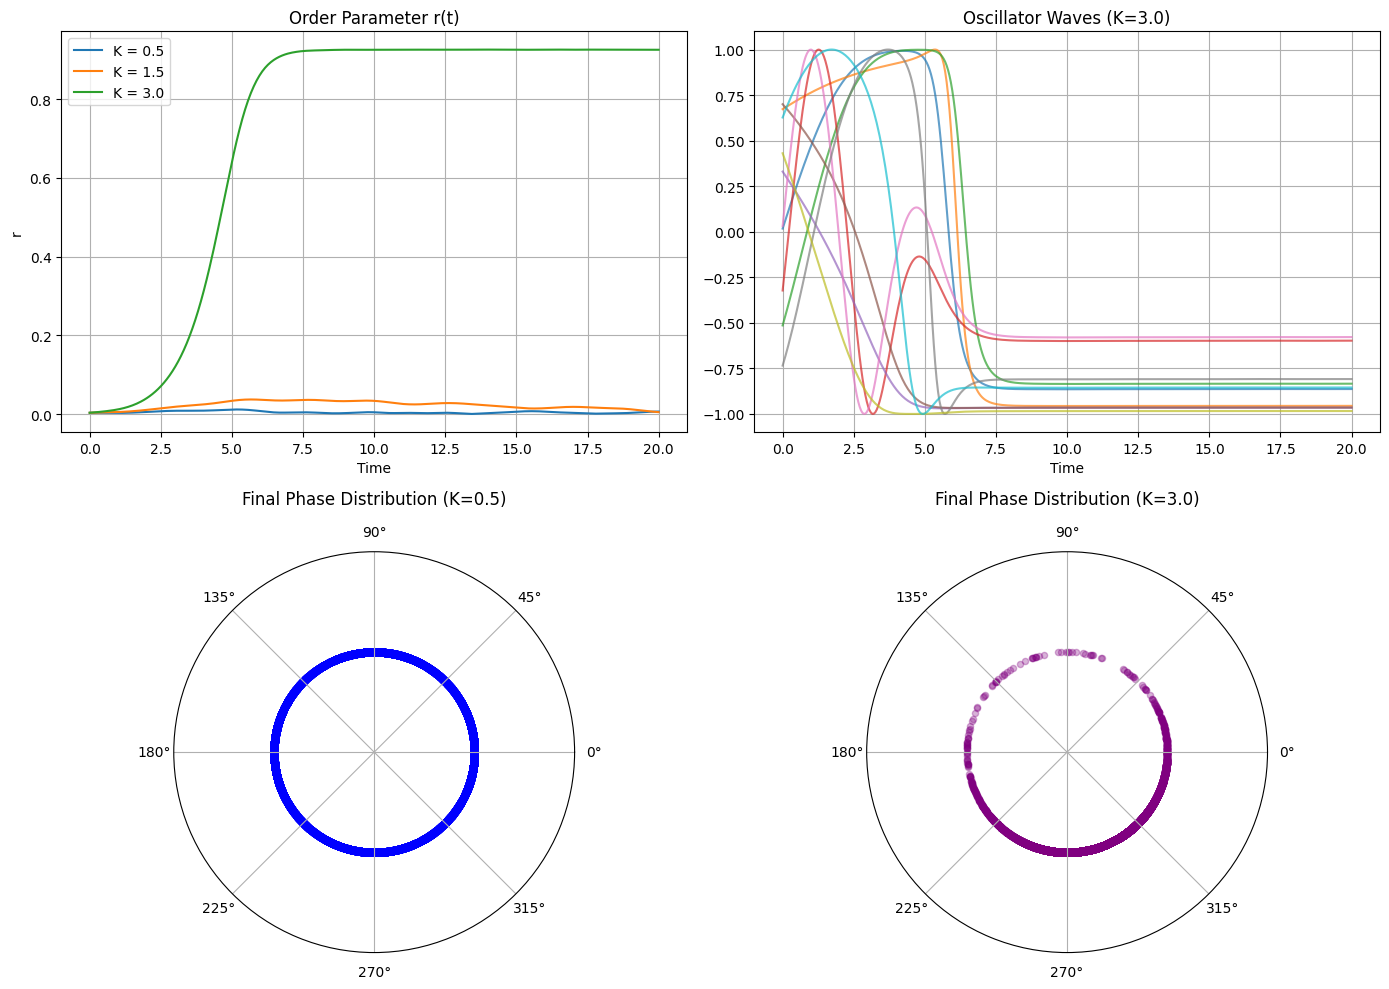

In [4]:
N_osc = 50000
t_max = 20.0
dt = 0.05
np.random.seed(42)
omega_500 = np.random.normal(0, 1.0, N_osc)
theta_init_500 = np.random.uniform(0, 2 * np.pi, N_osc)

results = {}
for K in [0.5, 1.5, 3.0]:
    t, phases, r = run_simulation(N_osc, K, omega_500, theta_init_500, t_max, dt)
    results[K] = {'t': t, 'phases': phases, 'r': r}

fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(221)
for K in [0.5, 1.5, 3.0]:
    ax1.plot(results[K]['t'], results[K]['r'], label=f'K = {K}')
ax1.set_title('Order Parameter r(t)')
ax1.set_xlabel('Time')
ax1.set_ylabel('r')
ax1.legend()
ax1.grid(True)

ax2 = fig.add_subplot(222)
for i in range(10):
    ax2.plot(results[3.0]['t'], np.sin(results[3.0]['phases'][i, :]), alpha=0.7)
ax2.set_title('Oscillator Waves (K=3.0)')
ax2.set_xlabel('Time')
ax2.grid(True)

ax3 = fig.add_subplot(223, polar=True)
ax3.scatter(results[0.5]['phases'][:, -1], np.ones(N_osc), c='blue', alpha=0.3, s=20)
ax3.set_title('Final Phase Distribution (K=0.5)', pad=15)
ax3.set_yticks([])

ax4 = fig.add_subplot(224, polar=True)
ax4.scatter(results[3.0]['phases'][:, -1], np.ones(N_osc), c='purple', alpha=0.3, s=20)
ax4.set_title('Final Phase Distribution (K=3.0)', pad=15)
ax4.set_yticks([])

plt.tight_layout()
plt.savefig(r"C:\Users\siddh\Downloads\MCS\fig1_dynamics.png", dpi=150, bbox_inches='tight')
plt.show()

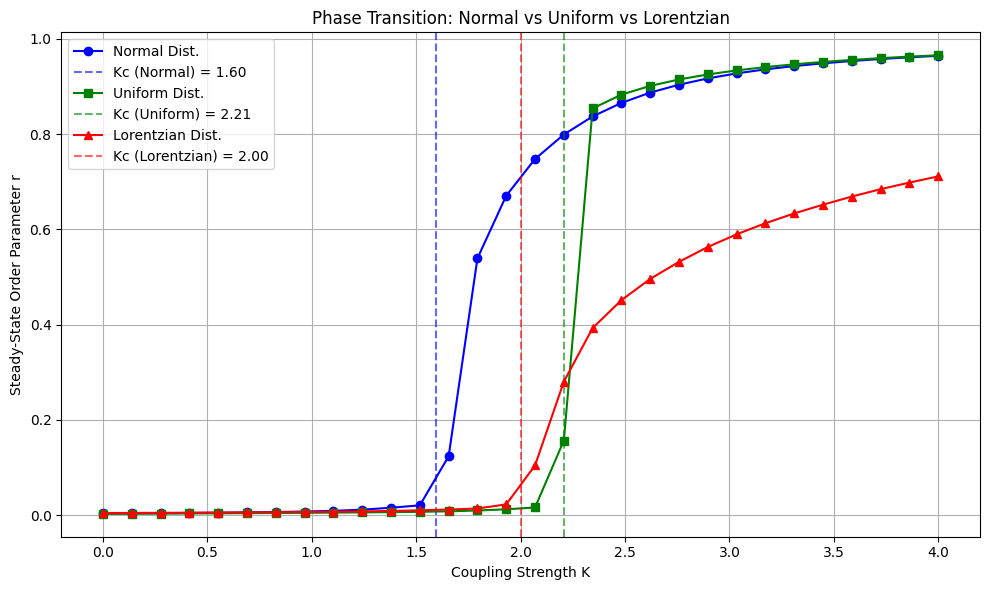

In [5]:
N_osc = 50000
np.random.seed(42)
theta_init_800 = np.random.uniform(0, 2 * np.pi, N_osc)

omega_norm = np.random.normal(0, 1.0, N_osc)
Kc_norm = np.sqrt(8 / np.pi)

a = np.sqrt(3)
omega_uni = np.random.uniform(-a, a, N_osc)
Kc_uni = (4 * a) / np.pi

gamma = 1.0
omega_lor = np.clip(gamma * np.random.standard_cauchy(N_osc), -50, 50)
Kc_lor = 2 * gamma

K_range = np.linspace(0.0, 4.0, 30)

r_norm = [simulate_steady_state(N_osc, K, omega_norm, theta_init_800, 40.0, 0.1, 25.0)[0] for K in K_range]
r_uni  = [simulate_steady_state(N_osc, K, omega_uni,  theta_init_800, 40.0, 0.1, 25.0)[0] for K in K_range]
r_lor  = [simulate_steady_state(N_osc, K, omega_lor,  theta_init_800, 40.0, 0.1, 25.0)[0] for K in K_range]

plt.figure(figsize=(10, 6))
plt.plot(K_range, r_norm, 'o-', color='blue',  label='Normal Dist.')
plt.axvline(Kc_norm, color='blue',  linestyle='--', alpha=0.6, label=f'Kc (Normal) = {Kc_norm:.2f}')
plt.plot(K_range, r_uni,  's-', color='green', label='Uniform Dist.')
plt.axvline(Kc_uni,  color='green', linestyle='--', alpha=0.6, label=f'Kc (Uniform) = {Kc_uni:.2f}')
plt.plot(K_range, r_lor,  '^-', color='red',   label='Lorentzian Dist.')
plt.axvline(Kc_lor,  color='red',   linestyle='--', alpha=0.6, label=f'Kc (Lorentzian) = {Kc_lor:.2f}')
plt.title('Phase Transition: Normal vs Uniform vs Lorentzian')
plt.xlabel('Coupling Strength K')
plt.ylabel('Steady-State Order Parameter r')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\siddh\Downloads\MCS\fig2_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

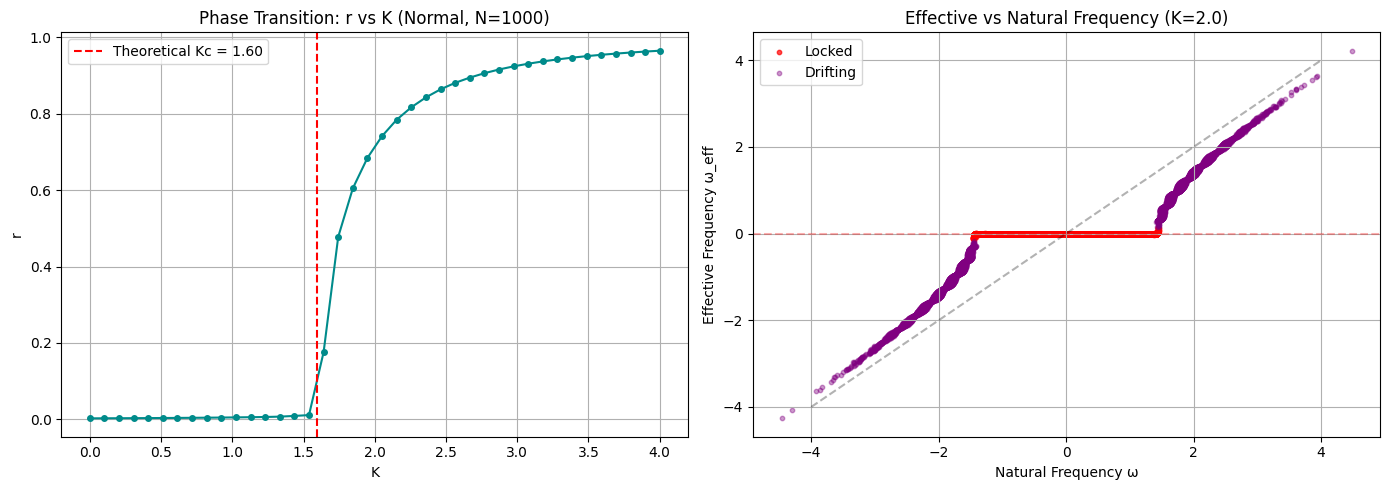

In [6]:
N_osc = 50000
np.random.seed(42)
omega_1000 = np.random.normal(0, 1.0, N_osc)
theta_init_1000 = np.random.uniform(0, 2 * np.pi, N_osc)

K_range_fine = np.linspace(0.0, 4.0, 40)
r_steady = []
for K in K_range_fine:
    r_avg, _ = simulate_steady_state(N_osc, K, omega_1000, theta_init_1000, 50.0, 0.1, 30.0)
    r_steady.append(r_avg)

_, eff_omega = simulate_steady_state(N_osc, 2.0, omega_1000, theta_init_1000, 50.0, 0.1, 30.0)

locked = np.abs(eff_omega - np.mean(eff_omega[np.abs(omega_1000) < 1.0])) < 0.15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range_fine, r_steady, 'o-', color='darkcyan', markersize=4)
ax1.axvline(np.sqrt(8 / np.pi), color='red', linestyle='--', label=f'Theoretical Kc = {np.sqrt(8/np.pi):.2f}')
ax1.set_title('Phase Transition: r vs K (Normal, N=1000)')
ax1.set_xlabel('K')
ax1.set_ylabel('r')
ax1.legend()
ax1.grid(True)

ax2.scatter(omega_1000[locked],  eff_omega[locked],  color='red',    s=10, alpha=0.7, label='Locked')
ax2.scatter(omega_1000[~locked], eff_omega[~locked], color='purple', s=10, alpha=0.4, label='Drifting')
ax2.plot([-4, 4], [-4, 4], 'k--', alpha=0.3)
ax2.axhline(0, color='red', linestyle='--', alpha=0.3)
ax2.set_title('Effective vs Natural Frequency (K=2.0)')
ax2.set_xlabel('Natural Frequency ω')
ax2.set_ylabel('Effective Frequency ω_eff')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(r"C:\Users\siddh\Downloads\MCS\fig3_transition.png", dpi=150, bbox_inches='tight')
plt.show()